In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v6_lane_vehicle.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v6_lane_vehicle.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 198)
(66060, 198)


In [4]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())
print()
print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [5]:
target_column = "behavior"

feature_columns = [
    col
    for col in train_dataset.columns
    if col not in [
        "behavior",
        "driver",
        "trip",
        "road_type"
    ]
]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 194)
(66060, 194)


In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [8]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [9]:
rf_pred = rf_model.predict(
    X_test
)

rf_pred[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6408


In [11]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.76      0.81     15257
      DROWSY       0.84      0.54      0.65     36143
      NORMAL       0.38      0.77      0.51     14660

    accuracy                           0.64     66060
   macro avg       0.70      0.69      0.66     66060
weighted avg       0.74      0.64      0.66     66060



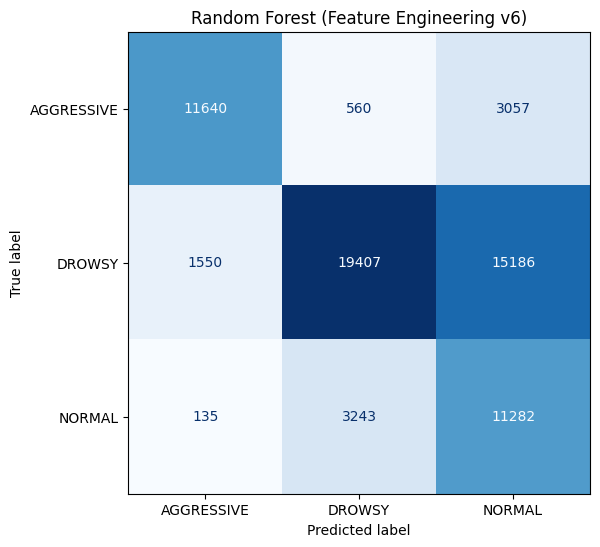

In [12]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest (Feature Engineering v6)")
plt.show()

In [13]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
28,speed_max,0.026263
94,lane_offset_q75,0.024341
34,speed_q75,0.023282
150,relative_speed_rms,0.023137
29,speed_median,0.020165
30,speed_rms,0.019215
33,speed_q25,0.018526
24,speed_mean,0.018512
27,speed_min,0.017297
88,lane_offset_max,0.016896


In [14]:
importance[
    importance["Feature"].str.contains(
        "lane_offset_velocity|ttc_trend",
        regex=True
    )
].sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
181,ttc_trend_std,0.012366
186,ttc_trend_rms,0.012362
182,ttc_trend_variance,0.012343
122,lane_offset_velocity_variance,0.005729
126,lane_offset_velocity_rms,0.005639
121,lane_offset_velocity_std,0.005378
184,ttc_trend_max,0.005229
123,lane_offset_velocity_min,0.005145
183,ttc_trend_min,0.005090
124,lane_offset_velocity_max,0.004419
